# 02_explore_data

This notebook only serves to explore the dataframe created in the previous notebook `01_find_tcp.ipynb`.

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

In [2]:
from modules.utils import load_calibration_parquet, build_color_map, load_flight_window, aggregate_calibration_data
from modules.ws import *

We set this configuration cell to explore the data from 7 Aug 2025. We will also load the data from the weather station and compare it to the measurements taken at the Luční bouda weather station maintained by the Czech Hydrometeorological Institute (CHMI).

In [3]:
DATE = "20250807"

ANCILLARY_DIR = "data/ancillary"
WEATHER_DIR = f"{ANCILLARY_DIR}/weather"

FIG_DIR = f"results/02_explore_data"
os.makedirs(FIG_DIR, exist_ok=True)
ALL_DATES = ["20250622", "20250807", "20250813", "20250814"]

date_str = datetime.strptime(DATE, "%Y%m%d").strftime("%d. %m. %Y")
aoi_path = f"{ANCILLARY_DIR}/aoi.shp"

In [4]:
df = load_calibration_parquet(DATE, ANCILLARY_DIR)
fs, fe = load_flight_window(DATE)

print(f"Flight window: {fs} – {fe}")

tcps_plate = [t for t in df.tcp_name.unique() if t.endswith('_plate')]
tcps_water = [t for t in df.tcp_name.unique() if t.endswith('_water')]

print(f"TCPs (plate): {tcps_plate}")
print(f"TCPs (water): {tcps_water}")

Flight window: 2025-08-07 13:43:45 – 2025-08-07 14:01:43
TCPs (plate): ['tcp1_plate', 'tcp3_plate', 'tcp5_plate', 'tcp6_plate']
TCPs (water): ['tcp3_water', 'tcp5_water']


Let's have a look at the dataframe from the previous notebook:

In [5]:
df

,timestamp,timestamp_seconds,tcp_name,img_temperature,surf_std,n_px,pt100_temperature,temperature_diff
0,2025-08-07 13:58:00,2025-08-07 13:58:39,tcp1_plate,59.299992,0.867470,152,53.35,-5.949992
1,2025-08-07 13:58:00,2025-08-07 13:58:41,tcp1_plate,59.799992,0.880247,151,53.35,-6.449992
2,2025-08-07 14:00:00,2025-08-07 14:00:21,tcp1_plate,60.299992,1.594727,153,54.92,-5.379992
3,2025-08-07 14:00:00,2025-08-07 14:00:23,tcp1_plate,60.050003,1.346610,149,54.92,-5.130003
4,2025-08-07 14:00:00,2025-08-07 14:00:25,tcp1_plate,60.449997,0.927242,138,54.92,-5.529997
5,2025-08-07 14:00:00,2025-08-07 14:00:48,tcp1_plate,61.100006,0.934975,111,54.92,-6.180006
6,2025-08-07 14:00:00,2025-08-07 14:00:50,tcp1_plate,60.899994,0.872637,150,54.92,-5.979994
7,2025-08-07 14:00:00,2025-08-07 14:00:52,tcp1_plate,61.500000,0.928168,147,54.92,-6.580000
0,2025-08-07 13:57:00,2025-08-07 13:57:13,tcp3_plate,44.600006,1.256812,144,42.60,-2.000006
1,2025-08-07 13:57:00,2025-08-07 13:57:13,tcp3_water,9.799988,0.063113,100,16.60,6.800012


Visualise the radiometric and skin temperatures for each TCP. The radiometric temperature corresponds to the median of the TCP region as seen by the H20T sensor; the skin temperature corresponds to the measurements taken by the PT100 sensor (of the plate and of the water).

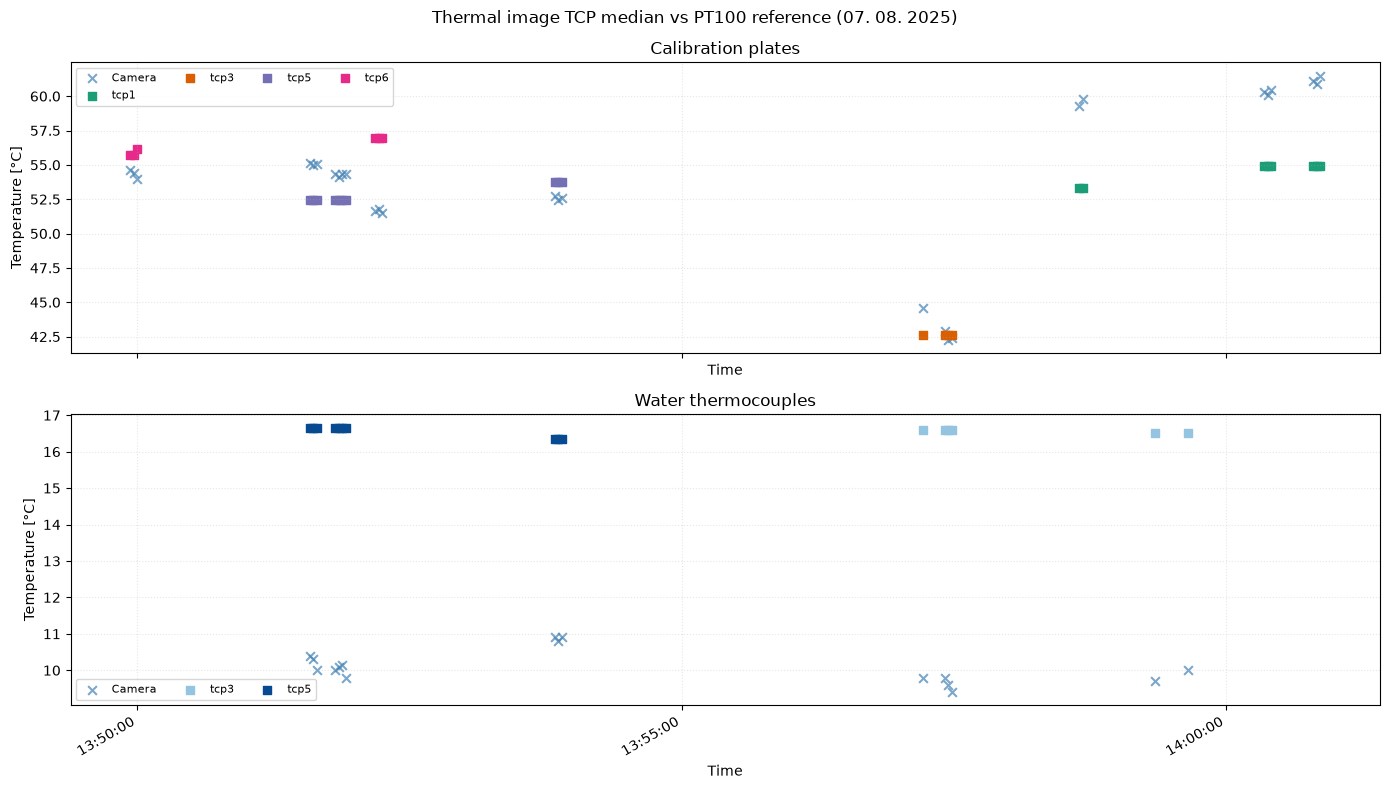

In [6]:
color_map = build_color_map(df.tcp_name.unique())
xfmt = mdates.DateFormatter('%H:%M:%S')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, tcps, title in zip(axes, [tcps_plate, tcps_water], ['Calibration plates', 'Water thermocouples']):
    first = True
    for tcp in tcps:
        sub = df[df.tcp_name == tcp].sort_values('timestamp_seconds')
        label = tcp.split('_')[0]
        ax.scatter(sub.timestamp_seconds, sub.img_temperature, color='steelblue', alpha=0.7, marker='x', s=40, label='Camera' if first else None)
        ax.scatter(sub.timestamp_seconds, sub.pt100_temperature, color=color_map[tcp], alpha=1, marker='s', s=40, label=label)
        first = False

    ax.xaxis.set_major_formatter(xfmt)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_xlabel('Time')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(title)
    ax.legend(ncol=4, fontsize=8)
    ax.grid(alpha=0.3, linestyle=':')
    ax.margins(y=0.05)

fig.suptitle(f'Thermal image TCP median vs PT100 reference ({date_str})', fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/tcp_vs_pt100_{DATE}.png", dpi=200)

We can observe that the camera systematically underestimates water temperature, while the pattern for the plate temperatures is unclear.

When we built the dataframe, we used all images in which the TCP was detected. This also includes many images taken only seconds apart. We can aggregate them by minute:

In [7]:
df_agg = aggregate_calibration_data(df)
print(f"Aggregated rows: {len(df_agg)} (from {len(df)} raw images)")
df_agg

Aggregated rows: 12 (from 44 raw images)


,tcp_name,timestamp,pt100_temperature,img_temperature,n_images,temperature_diff
0,tcp1_plate,2025-08-07 13:58:00,53.35,59.549992,2,-6.199992
1,tcp1_plate,2025-08-07 14:00:00,54.92,60.716663,6,-5.796663
2,tcp3_plate,2025-08-07 13:57:00,42.60,43.037498,4,-0.437498
3,tcp3_water,2025-08-07 13:57:00,16.60,9.649994,4,6.950006
4,tcp3_water,2025-08-07 13:59:00,16.50,9.850006,2,6.649994
5,tcp5_plate,2025-08-07 13:51:00,52.48,54.621429,7,-2.141429
6,tcp5_plate,2025-08-07 13:53:00,53.75,52.583340,3,1.166660
7,tcp5_water,2025-08-07 13:51:00,16.66,10.107141,7,6.552859
8,tcp5_water,2025-08-07 13:53:00,16.36,10.866658,3,5.493342
9,tcp6_plate,2025-08-07 13:49:00,55.70,54.500000,2,1.200000


And again see the relationship between the two temperature measurements, for the aggregated data, in a simple scatterplot:

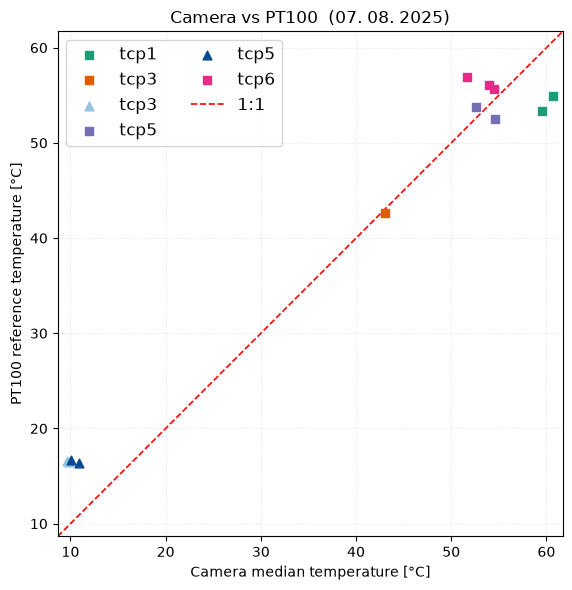

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

for tcp in sorted(df_agg.tcp_name.unique()):
    sub = df_agg[df_agg.tcp_name == tcp]
    ax.scatter(sub.img_temperature, sub.pt100_temperature,
               color=color_map[tcp], s=40,
               marker="s" if tcp.endswith("_plate") else "^",
               label=tcp.split("_")[0], zorder=3)

lims = [min(df_agg.img_temperature.min(), df_agg.pt100_temperature.min()) - 1,
        max(df_agg.img_temperature.max(), df_agg.pt100_temperature.max()) + 1]
ax.plot(lims, lims, color="red", lw=1.2, linestyle="--", label="1:1", zorder=1)

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Camera median temperature [°C]")
ax.set_ylabel("PT100 reference temperature [°C]")
ax.set_title(f"Camera vs PT100  ({date_str})")
ax.legend(fontsize=12, ncol=2)
ax.set_aspect("equal")
ax.grid(alpha=0.3, linestyle=":")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/tcp_vs_pt100_scatter_{DATE}.png", dpi=200)

In thermal remote sensing, context matters - what were the weather conditions like during the flight campaign on 7 Aug 2025, according to the weather station at the site?

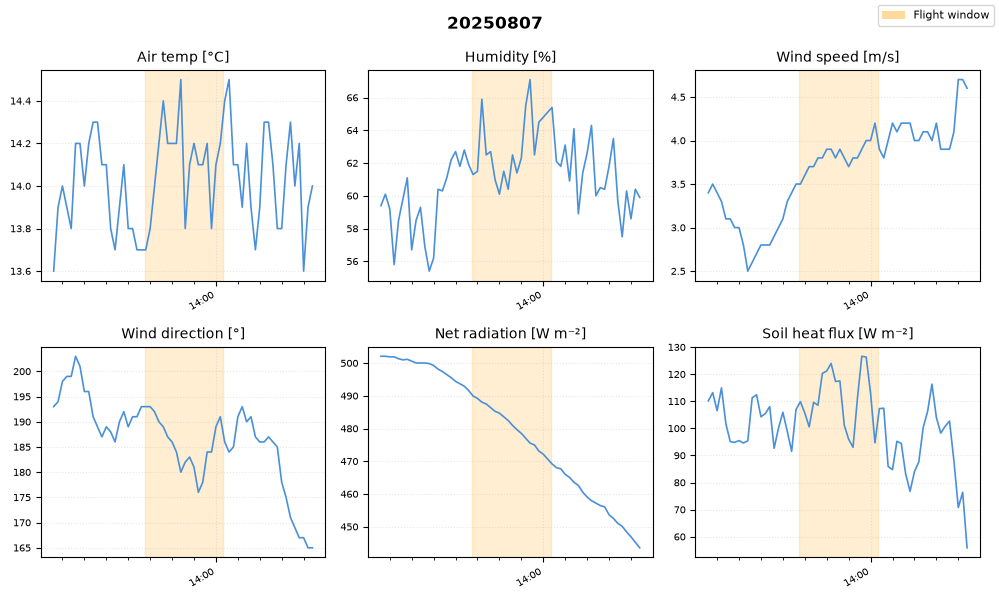

In [9]:
colors_date = {
    #"20250622": "#e07b39",
    "20250807": "#4a90d9",
    #"20250813": "#7cb87c",
    #"20250814": "#c966cc"
}

panel_vars = [
    ("rvt81_temp_2m", "Air temp [°C]"),
    ("rvt81_rh_2m", "Humidity [%]"),
    ("ws200_wind_speed", "Wind speed [m/s]"),
    ("ws200_wind_dir", "Wind direction [°]"),
    ("nr_lite2_net_radiation", "Net radiation [W m⁻²]"),
    ("hukseflux_heat_flux", "Soil heat flux [W m⁻²]")
]

xfmt2 = mdates.DateFormatter("%H:%M")
flight_windows = {}

n_rows = 2
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6), squeeze=False)

col = colors_date[DATE]
df_met_d = load_meteo_data(DATE, WEATHER_DIR)
t_centre = fs + (fe - fs) / 2
t_before = t_centre - pd.Timedelta(hours=0.5)
t_after = t_centre + pd.Timedelta(hours=0.5) #half an hour before and after the flight window context
df_w = df_met_d[(df_met_d.datetime >= t_before) & (df_met_d.datetime <= t_after)].copy()

for c, (var, ylabel) in enumerate(panel_vars[:3]):
    ax = axes[0][c]

    ax.plot(df_w.datetime, df_w[var], lw=1.2, color=col)
    ax.axvspan(fs, fe, alpha=0.18, color="orange", zorder=0)

    ax.xaxis.set_major_formatter(xfmt2)
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(alpha=0.3, linestyle=":")
    ax.set_title(ylabel, fontsize=10)

for c, (var, ylabel) in enumerate(panel_vars[3:]):
    ax = axes[1][c]

    ax.plot(df_w.datetime, df_w[var], lw=1.2, color=col)
    ax.axvspan(fs, fe, alpha=0.18, color="orange", zorder=0)

    ax.xaxis.set_major_formatter(xfmt2)
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(alpha=0.3, linestyle=":")
    ax.set_title(ylabel, fontsize=10)
        
fig.suptitle(DATE, fontsize=12, fontweight="bold")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor="orange", alpha=0.4, label="Flight window")], loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()
fig.savefig(f"{FIG_DIR}/meteo_panel_{DATE}.png", dpi=200)

The weather conditions were stable during this flight, as evidenced by the table below:

In [10]:
summary_cols = [pan[0] for pan in panel_vars]
print(f"Flight window summary ({DATE}) {fs.strftime('%H:%M')}–{fe.strftime('%H:%M')})")
print(df_w[[c for c in summary_cols if c in df_w.columns]].describe().loc[["mean", "std", "min", "max"]].round(2).to_string())

Flight window summary (20250807) 13:43–14:01)
      rvt81_temp_2m  rvt81_rh_2m  ws200_wind_speed  ws200_wind_dir  nr_lite2_net_radiation  hukseflux_heat_flux
mean          14.03        61.17              3.66          186.52                  478.88               101.38
std            0.23         2.50              0.53            8.62                   18.53                13.62
min           13.60        55.40              2.50          165.00                  443.56                55.91
max           14.50        67.10              4.70          203.00                  502.10               126.64


How do these measurements compare to those taken at the nearby Luční bouda weather station (~650 m away)?

In [11]:
YYYYMM = DATE[:6]
df_met_date = load_meteo_data(DATE, WEATHER_DIR)

df_chmu = download_chmu_10min(YYYYMM, date_filter=DATE)
df_chmu_w = df_chmu[(df_chmu.index >= t_before) & (df_chmu.index <= t_after)]

print(f"ČHMÚ Luční bouda: {len(df_chmu)} 10-min records for {DATE}")
print(f"Columns: {df_chmu.columns.tolist()}")

https://opendata.chmi.cz/meteorology/climate/historical/data/10min/2025/10m-0-203-0-11633-202508.json
ČHMÚ Luční bouda: 144 10-min records for 20250807
Columns: ['Casmax', 'D', 'Dmax', 'Dprum', 'F', 'Fmax', 'Fprum', 'H', 'REUV10', 'RGLB10', 'SCEa', 'SRA10M', 'SSV10M', 'T', 'T05', 'T10', 'T100', 'T20', 'T50', 'TMA', 'TMI', 'TPM']


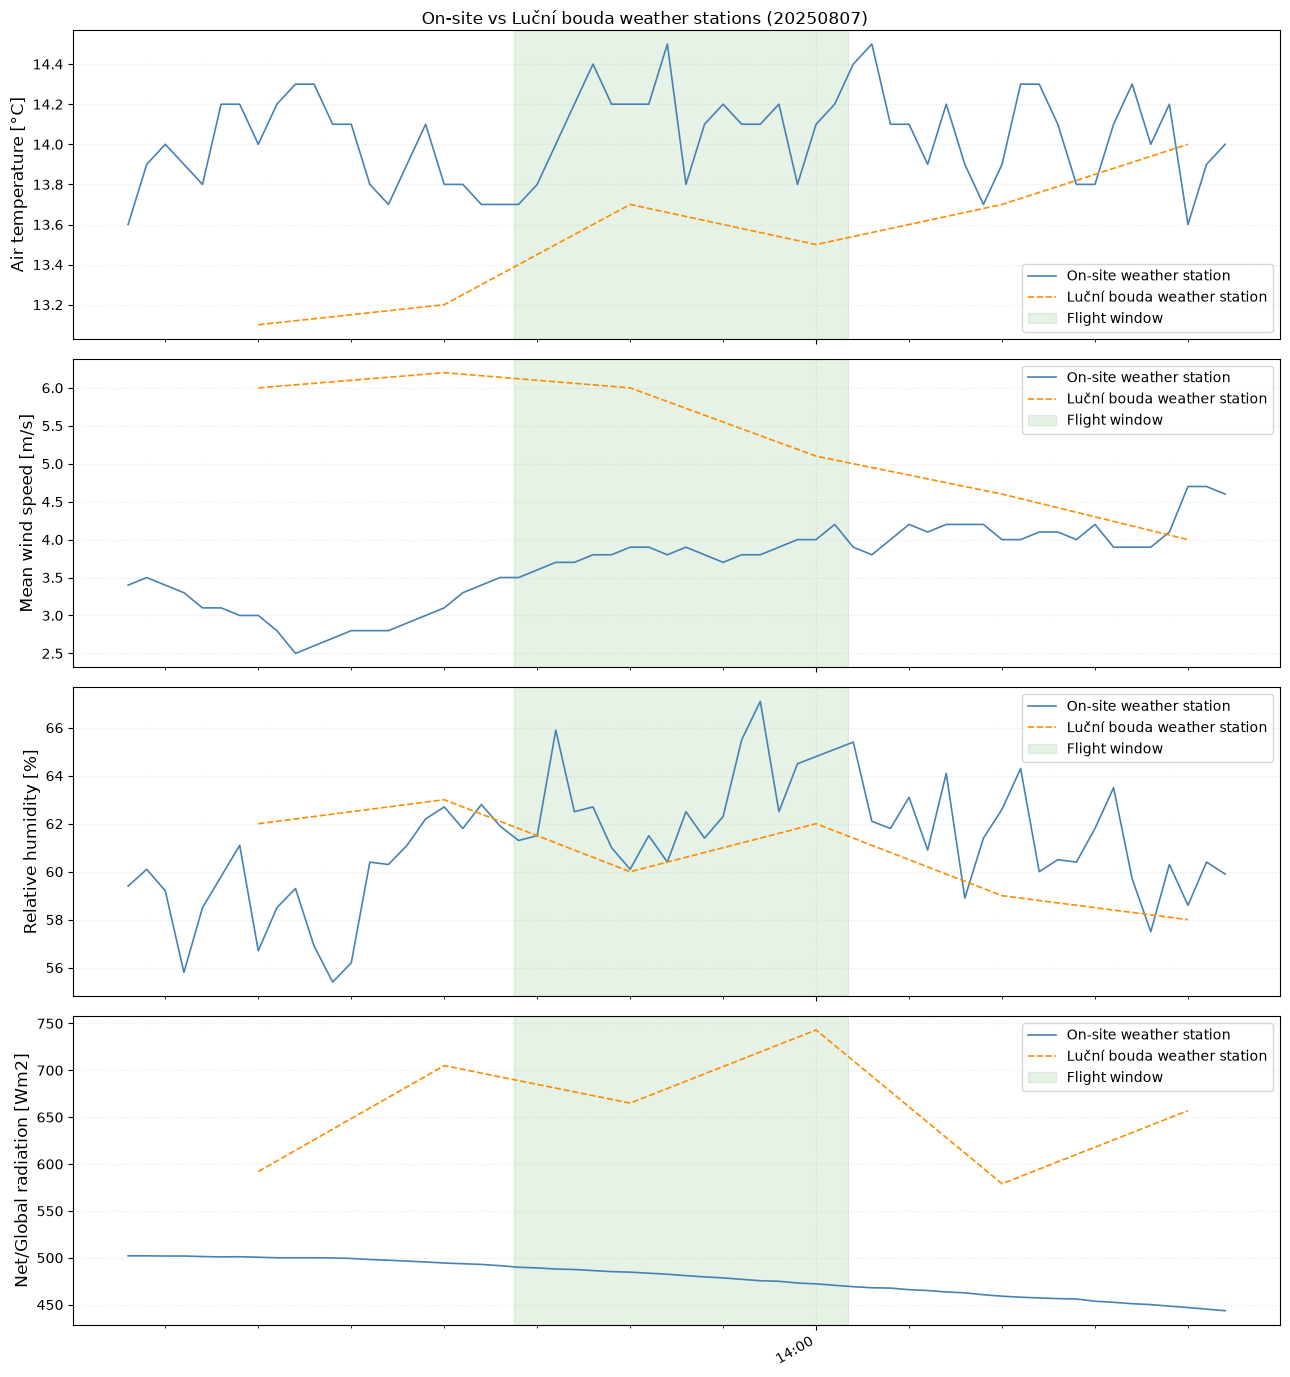

In [12]:
comp_panels = [
    ("rvt81_temp_2m", "T", "Air temperature [°C]"),
    ("ws200_wind_speed", "Fprum", "Mean wind speed [m/s]"),
    ("rvt81_rh_2m", "H", "Relative humidity [%]"),
    ("nr_lite2_net_radiation", "RGLB10", "Net/Global radiation [Wm2]")
]

fig, axes = plt.subplots(4, 1,  figsize=(13, 14), sharex=True)
for ax, (ur_col, chmu_col, ylabel) in zip(axes, comp_panels):
    if ur_col in df_w.columns:
        ax.plot(df_w.datetime, df_w[ur_col], lw=1.2, color="steelblue", label="On-site weather station")
    if chmu_col in df_chmu_w.columns:
        ax.plot(df_chmu_w.index, df_chmu_w[chmu_col].astype(float), lw=1.2, color="darkorange", linestyle="--", label="Luční bouda weather station")

    ax.axvspan(fs, fe, alpha=0.1, color="green", label="Flight window")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle=":")
    ax.xaxis.set_major_formatter(xfmt2)
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55]))

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)

    fig.suptitle(f"On-site vs Luční bouda weather stations ({DATE})", fontsize=12)
    fig.tight_layout()
